In [1]:
import polars as pl
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import utils

import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator, FormatStrFormatter
from matplotlib.colors import LinearSegmentedColormap

# Global analysis of ERC-20 and ERC-721 token transfers

We first count the total number of contracts and triggered transfer events for the ERC-20 and ERC-721 standards.

In [2]:
ft_rank = pl.read_csv("results/ft/ft_ranking.csv")
nft_rank = pl.read_csv("results/nft/nft_ranking.csv")
print("N. of ERC-20 contracts: ", len(ft_rank))
print("N. of ERC-20 transfers: ", ft_rank['count'].sum())

N. of ERC-20 contracts:  386615
N. of ERC-20 transfers:  961603795


In [14]:
!wc -l data/nft/erc721_transfers.csv data/nft/erc721_contracts.csv

 107384863 data/nft/erc721_transfers.csv
     83041 data/nft/erc721_contracts.csv
 107467904 total


We first plot the frequency distributions of transfer events among contracts.

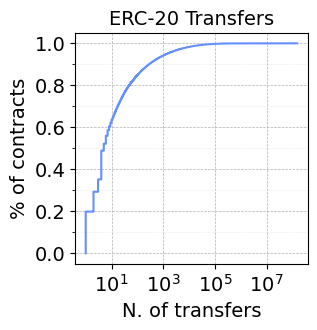

In [11]:
data = ft_rank['count'].to_numpy()
sorted_data = np.sort(data)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('% of contracts')
ax.set_xscale('log')
ax.step(sorted_data, np.arange(sorted_data.size)/sorted_data.size, color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_cumulative_transfers_contract.pdf", format='pdf', bbox_inches='tight')
plt.show()

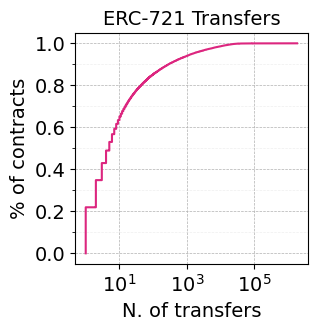

In [12]:
data = nft_rank['count'].to_numpy()
sorted_data = np.sort(data)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('% of contracts')
ax.set_xscale('log')
ax.step(sorted_data, np.arange(sorted_data.size)/sorted_data.size, color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_cumulative_transfers_contract.pdf", format='pdf', bbox_inches='tight')
plt.show()

Import the ERC-20 and ERC-721 statistics for each block.

In [19]:
ft_block_stats = pl.read_csv("results/ft/ft_block_stats.csv", try_parse_dates=True)
nft_block_stats = pl.read_csv("results/nft/nft_block_stats.csv", try_parse_dates=True)

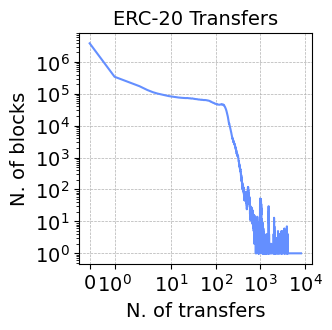

In [4]:
data = ft_block_stats['num_transfers'].value_counts(name="num_blocks").sort("num_transfers")
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of blocks')
ax.set_xscale('symlog')
ax.set_yscale('log')
ax.plot(data['num_transfers'], data['num_blocks'], color='#648fff')
ax.grid(linestyle='--', linewidth=0.5)
#ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_dist_transfers_block.pdf", format='pdf', bbox_inches='tight')
plt.show()

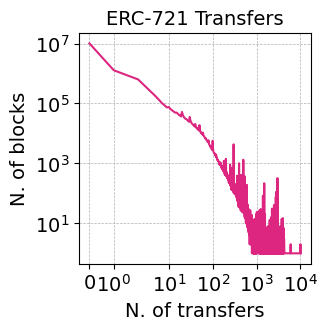

In [5]:
data = nft_block_stats['num_transfers'].value_counts(name="num_blocks").sort("num_transfers")
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of blocks')
ax.set_xscale('symlog')
ax.set_yscale('log')
ax.plot(data['num_transfers'], data['num_blocks'], color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_dist_transfers_block.pdf", format='pdf', bbox_inches='tight')
plt.show()

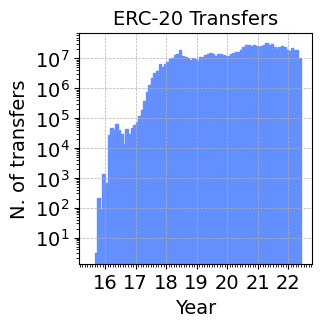

In [10]:
data = (ft_block_stats
    .drop("num_contracts")
    .group_by_dynamic("timestamp", every="1mo")
    .agg(pl.col("num_transfers").sum()))

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot()
ax.set_title('ERC-20 Transfers')
ax.set_xlabel('Year')
ax.set_ylabel('N. of transfers')
ax.set_yscale('log')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator(12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.fill_between(data['timestamp'], data['num_transfers'], step="pre", color='#648fff')
ax.grid(linestyle='--', linewidth=0.5)
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_temporal_total_transfers.pdf", format='pdf', bbox_inches='tight')
plt.show()

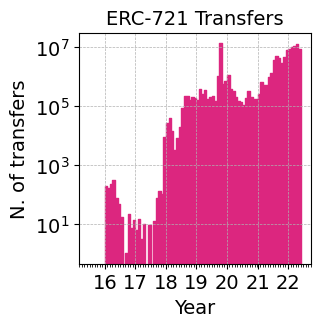

In [11]:
data = (nft_block_stats
    .drop("num_contracts")
    .group_by_dynamic("timestamp", every="1mo")
    .agg(pl.col("num_transfers").sum()))

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot()
ax.set_title('ERC-721 Transfers')
ax.set_xlabel('Year')
ax.set_ylabel('N. of transfers')
ax.set_yscale('log')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator(12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.fill_between(data['timestamp'], data['num_transfers'], step="pre", color='#dc267f')
ax.grid(linestyle='--', linewidth=0.5)
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_temporal_total_transfers.pdf", format='pdf', bbox_inches='tight')
plt.show()

We list the top 5 services by number of raised ERC-721 transfer events during November 2019.

In [13]:
TIMESTAMP_FILE = "data/block_timestamps_0-14999999.csv"
NFT_TRANSFERS_FILE = "data/nft/erc721_transfers.csv"
timestamps = pl.read_csv(TIMESTAMP_FILE, has_header=False, new_columns=['block_id','timestamp'])
timestamps = timestamps.with_columns(timestamp=pl.from_epoch(pl.col("timestamp"), time_unit="s"))
nft_tdf = pl.read_csv(NFT_TRANSFERS_FILE, has_header=False, new_columns=["block_id", "contract_id", "from_id", "to_id"])
nft_tdf = nft_tdf.join(timestamps, on="block_id", how="left")
nft_tdf

block_id,contract_id,from_id,to_id,timestamp
i64,i64,i64,i64,datetime[μs]
937821,0,1,1,2016-02-01 15:00:18
937821,0,2,1,2016-02-01 15:00:18
952792,0,1,3,2016-02-04 14:22:04
952792,0,1,4,2016-02-04 14:22:04
952899,0,1,5,2016-02-04 14:52:32
…,…,…,…,…
14999999,2846,1682966,1360320,2022-06-21 02:28:10
14999999,2846,2600890,1360320,2022-06-21 02:28:10
14999999,2846,3265724,1360320,2022-06-21 02:28:10


In [18]:
NFT_CONTRACTS_FILE = "data/nft/erc721_contracts.csv"
contracts = pl.read_csv(NFT_CONTRACTS_FILE, has_header=False, new_columns=['contract_address', 'contract_id'])
(nft_tdf
    .filter((pl.col("timestamp") >= pl.datetime(2019, 11, 1)) & (pl.col("timestamp") <= pl.datetime(2019, 11, 30)))
    .group_by("contract_id").len(name="num_transfers").sort("num_transfers", descending=True).head(5)
    .join(contracts, on="contract_id", how="left")
)

contract_id,num_transfers,contract_address
i64,u32,str
2147,6946089,"""0e3a2a1f2146d86a604adc220b4967…"
2038,6680552,"""629cdec6acc980ebeebea9e5003bcd…"
144,37752,"""8853b05833029e3cf8d3cbb592f978…"
784,26997,"""bd13e53255ef917da7557db1b7d2d5…"
1038,24585,"""fac7bea255a6990f749363002136af…"
